In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
path=r"C:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\Data\Combined Data.csv"
df=pd.read_csv(path)
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df=df.drop("Unnamed: 0",axis=1)

In [6]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


In [8]:
df=df.dropna(subset="statement",axis=0)

In [9]:
df['status'].nunique()

7

In [10]:
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

<Axes: xlabel='status'>

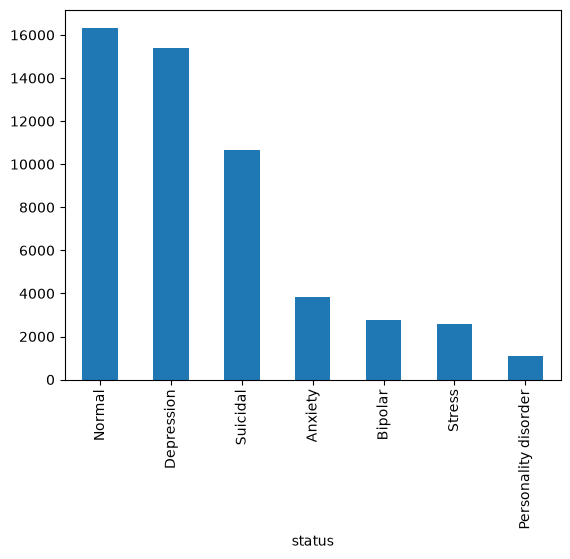

In [11]:
df['status'].value_counts().plot(kind='bar')

In [12]:
import re

df['statement'].str.lower()
df['statement'] = df['statement'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x)
)

df['statement'] = df['statement'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [13]:
df['statement'].isnull().sum()

np.int64(0)

In [14]:
import nltk
from nltk.stem import SnowballStemmer
stemmer=SnowballStemmer("english")
df['statement']=df['statement'].apply(lambda text:" ".join(stemmer.stem(word) for word in text.split()))

In [15]:
from sklearn.model_selection import train_test_split

X = df["statement"]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(42144,)
(42144,)
(10537,)
(10537,)


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [18]:
y_pred = model.predict(X_test_tfidf)
y_pred

array(['Suicidal', 'Bipolar', 'Suicidal', ..., 'Normal', 'Normal',
       'Suicidal'], shape=(10537,), dtype=object)

In [19]:
print(y_pred[:10])
print(y_test[:10].values)

['Suicidal' 'Bipolar' 'Suicidal' 'Normal' 'Depression' 'Depression'
 'Depression' 'Normal' 'Normal' 'Anxiety']
<StringArray>
[            'Suicidal',              'Bipolar',             'Suicidal',
               'Normal', 'Personality disorder',           'Depression',
           'Depression',               'Normal',               'Normal',
              'Anxiety']
Length: 10, dtype: str


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

             Anxiety       0.82      0.76      0.79       768
             Bipolar       0.85      0.71      0.77       556
          Depression       0.71      0.75      0.73      3081
              Normal       0.86      0.94      0.90      3269
Personality disorder       0.75      0.54      0.63       215
              Stress       0.62      0.46      0.53       517
            Suicidal       0.71      0.67      0.69      2131

            accuracy                           0.77     10537
           macro avg       0.76      0.69      0.72     10537
        weighted avg       0.77      0.77      0.77     10537



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 580   14   56   64    7   47    0]
 [  13  396   75   41    6   21    4]
 [  35   28 2316  132   13   22  535]
 [  21    6   79 3078    7   43   35]
 [   6    7   45   26  117   12    2]
 [  49   15   93  103    5  237   15]
 [   2    2  579  128    0    1 1419]]


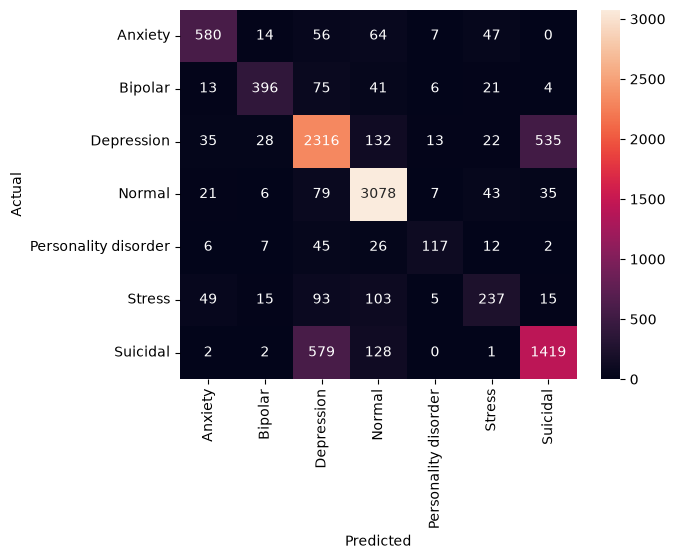

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(
    class_weight="balanced"
)

model_svm.fit(X_train_tfidf, y_train)

y_pred_svm = model_svm.predict(X_test_tfidf)

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

                      precision    recall  f1-score   support

             Anxiety       0.77      0.80      0.79       768
             Bipolar       0.77      0.82      0.79       556
          Depression       0.77      0.67      0.72      3081
              Normal       0.89      0.92      0.91      3269
Personality disorder       0.58      0.72      0.64       215
              Stress       0.54      0.60      0.57       517
            Suicidal       0.67      0.71      0.69      2131

            accuracy                           0.77     10537
           macro avg       0.71      0.75      0.73     10537
        weighted avg       0.77      0.77      0.77     10537



In [25]:
from sklearn.metrics import confusion_matrix

cm2 = confusion_matrix(y_test, y_pred)
print(cm2)

[[ 580   14   56   64    7   47    0]
 [  13  396   75   41    6   21    4]
 [  35   28 2316  132   13   22  535]
 [  21    6   79 3078    7   43   35]
 [   6    7   45   26  117   12    2]
 [  49   15   93  103    5  237   15]
 [   2    2  579  128    0    1 1419]]


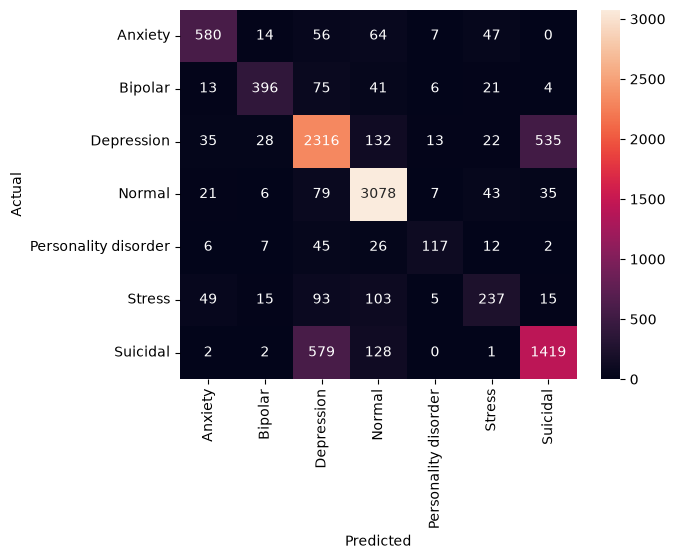

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
text = "I am feeling nervous"

# Same preprocessing
text = text.lower()
text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
text = re.sub(r'\s+', ' ', text).strip()

# Stemming
text = " ".join(stemmer.stem(word) for word in text.split())

# Convert to TF-IDF
text_tfidf = tfidf.transform([text])

# Predict
prediction = model_svm.predict(text_tfidf)

print("Prediction:", prediction[0])

Prediction: Anxiety


In [28]:
texts = [
    "I am feeling nervous",
    "I cannot sleep and my mind is restless",
    "I feel extremely sad and hopeless",
    "Everything is going well and I am happy",
    "I am under a lot of pressure and stress"
]

for text in texts:
    texts = text.lower()
    texts = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    texts = re.sub(r'\s+', ' ', text).strip()

# Stemming
    texts = " ".join(stemmer.stem(word) for word in text.split())

    vector = tfidf.transform([texts])
    prediction = model_svm.predict(vector)[0]

    print(f"{text} → {prediction}")

I am feeling nervous → Anxiety
I cannot sleep and my mind is restless → Anxiety
I feel extremely sad and hopeless → Depression
Everything is going well and I am happy → Depression
I am under a lot of pressure and stress → Stress


In [29]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_nb))

                      precision    recall  f1-score   support

             Anxiety       0.89      0.05      0.10       768
             Bipolar       0.67      0.00      0.01       556
          Depression       0.36      0.98      0.52      3081
              Normal       0.95      0.52      0.68      3269
Personality disorder       0.00      0.00      0.00       215
              Stress       0.00      0.00      0.00       517
            Suicidal       0.82      0.08      0.15      2131

            accuracy                           0.47     10537
           macro avg       0.53      0.23      0.21     10537
        weighted avg       0.67      0.47      0.40     10537



c:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tfidf.fit(X_train_tfidf, y_train)

y_pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_rf_tfidf))

                      precision    recall  f1-score   support

             Anxiety       0.81      0.75      0.78       768
             Bipolar       0.89      0.70      0.78       556
          Depression       0.68      0.65      0.66      3081
              Normal       0.82      0.94      0.87      3269
Personality disorder       1.00      0.37      0.54       215
              Stress       0.69      0.41      0.51       517
            Suicidal       0.62      0.67      0.64      2131

            accuracy                           0.74     10537
           macro avg       0.79      0.64      0.68     10537
        weighted avg       0.74      0.74      0.73     10537



In [31]:
import joblib

joblib.dump(model_svm, "models/tfidf_svm.pkl")

['models/tfidf_svm.pkl']

In [32]:
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']